<h1> Лабораторная работа 2 </h1>

<h2>Технологии программирования </h2>

<h3> Выполнил: </h3> 
<h4> Толстых Максим Алексеевич </h4>

<h3> Группа: </h3>
<h4> НММбд-02-22 </h4>

<h2> Цель работы </h2>

Изучить методы оценки статических характеристик, связанных с
распределением пользователей на плоскости

<h3> Задание 1 </h3>

Сгенерировали выборку случайных чисел размером 100 и 1000 для двух
распределений – экспоненциального и нормального. Для созданных
выборок сделали следующее:

<h3> Задание 1.1 </h3>
Посчитали выборочное среднее и дисперсию, сравнили с
математическим ожиданием соответствующих распределений.

In [453]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

In [454]:
exp_100 = np.random.exponential(1, size=100) #Нормальное распределение, выборка из 100
exp_1000 = np.random.exponential(1, size=1000)  #Нормальное распределение, выборка из 1000

norm_100 = np.random.normal(0, 1, size=100) #Экспотенциальное распределение, выборка из 100
norm_1000 = np.random.normal(0, 1, size=1000) #Экспотенциальное распределение, выборка из 1000

In [455]:
print('mean exp_100', np.mean(exp_100), '| var exp_100', np.var(exp_100), '| exp_var_theory = 1, exp_mean_theory = 1')
print('mean exp_1000', np.mean(exp_1000), '| var exp_1000', np.var(exp_1000), '| exp_var_theory = 1, exp_mean_theory = 1')

print('mean norm_100', np.mean(norm_100), '| var norm_100', np.var(norm_100), '| norm_var_theory = 1, norm_mean_theory = 0')
print('mean norm_1000', np.mean(norm_1000), '| var norm_1000', np.var(norm_1000), '| norm_var_theory = 1, norm_mean_theory = 0')


mean exp_100 0.9648379906190283 | var exp_100 0.8889147988722091 | exp_var_theory = 1, exp_mean_theory = 1
mean exp_1000 1.0017933822680198 | var exp_1000 1.0538451058497267 | exp_var_theory = 1, exp_mean_theory = 1
mean norm_100 0.0030056958021335146 | var norm_100 0.9908591288833415 | norm_var_theory = 1, norm_mean_theory = 0
mean norm_1000 0.0009838720263411122 | var norm_1000 0.9768543348157416 | norm_var_theory = 1, norm_mean_theory = 0


<h3> Задание 1.2 </h3>
Посчитали 0.5 и 0.99 квантили, сравнили с соответствующими
теоретическими значениями.

In [456]:
print('Квантиль 0,5 для exp_100', np.quantile(exp_100, 0.5), '| табличное значение', 0.693147)
print('Квантиль 0,99 для exp_100', np.quantile(exp_100, 0.99), '| табличное значение', 4.6 )

print('Квантиль 0,5 для exp_1000', np.quantile(exp_1000, 0.5), '| табличное значение', 0.693147)
print('Квантиль 0,99 для exp_1000', np.quantile(exp_1000, 0.99), '| табличное значение', 4.6)

print('Квантиль 0,5 для norm_100', np.quantile(norm_100, 0.5), '| табличное значение', 0)
print('Квантиль 0,99 для norm_100', np.quantile(norm_100, 0.99), '| табличное значение', 2.326)

print('Квантиль 0,5 для exp_100', np.quantile(norm_1000, 0.5), '| табличное значение', 0)
print('Квантиль 0,99 для exp_100', np.quantile(norm_1000, 0.99), '| табличное значение', 2.326)

Квантиль 0,5 для exp_100 0.7042044779222445 | табличное значение 0.693147
Квантиль 0,99 для exp_100 3.685222109487962 | табличное значение 4.6
Квантиль 0,5 для exp_1000 0.6922234051647231 | табличное значение 0.693147
Квантиль 0,99 для exp_1000 4.951739016263019 | табличное значение 4.6
Квантиль 0,5 для norm_100 0.13695557415590623 | табличное значение 0
Квантиль 0,99 для norm_100 1.8569614053089365 | табличное значение 2.326
Квантиль 0,5 для exp_100 -0.004672880424681406 | табличное значение 0
Квантиль 0,99 для exp_100 2.390470283014612 | табличное значение 2.326


<h3> Задание 1.3 </h3>
Построили гистограммы распределений.

<function matplotlib.pyplot.show(close=None, block=None)>

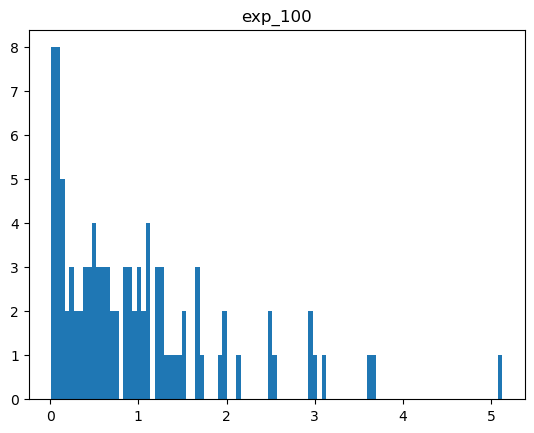

In [457]:
plt.hist(exp_100, bins=100)
plt.title('exp_100')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

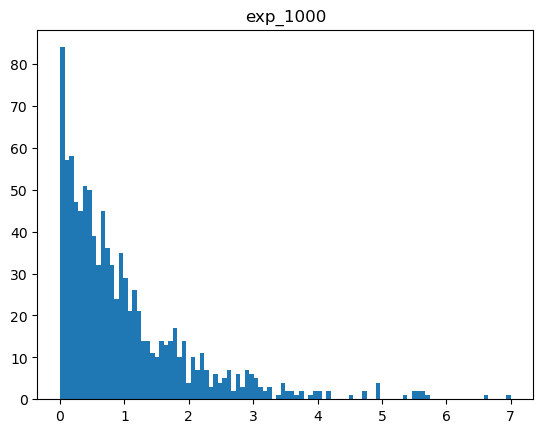

In [458]:
plt.hist(exp_1000, bins=100)
plt.title('exp_1000')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

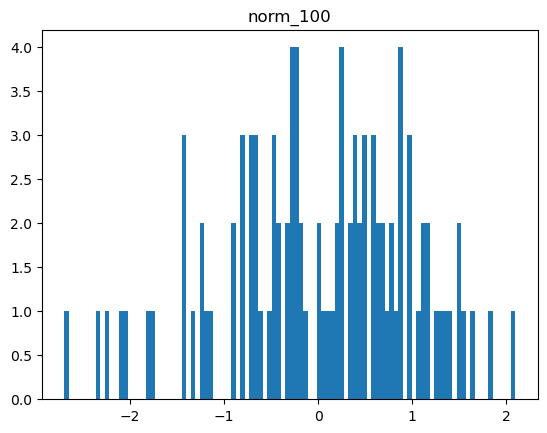

In [459]:
plt.hist(norm_100, bins=100)
plt.title('norm_100')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

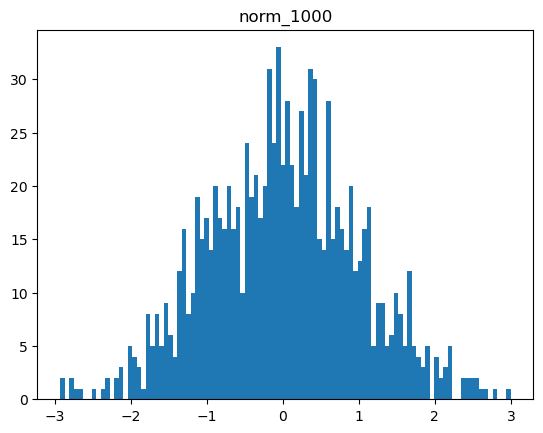

In [460]:
plt.hist(norm_1000, bins=100)
plt.title('norm_1000')
plt.show

<h3> Задание 1.4 </h3>
Построили функцию распределения случайной величины на основе
выборки (на одном графике показали функции распределения,
полученные из выборок разного размера и теоретическую);

In [461]:
def fun_exp(lambd, x):
    return 1 - np.exp(- lambd * x)

In [462]:
theory_exp_x = np.linspace(0, 10, 100)
theory_exp_y = fun_exp(1, theory_exp_x)

In [463]:
exp_100_copy = np.copy(exp_100)
exp_1000_copy = np.copy(exp_1000)

In [464]:
exp_100_copy.sort()
exp_1000_copy.sort()

In [465]:
exp_100_copy_y = np.arange(0., 1., 0.01)
exp_1000_copy_y = np.arange(0., 1., 0.001)

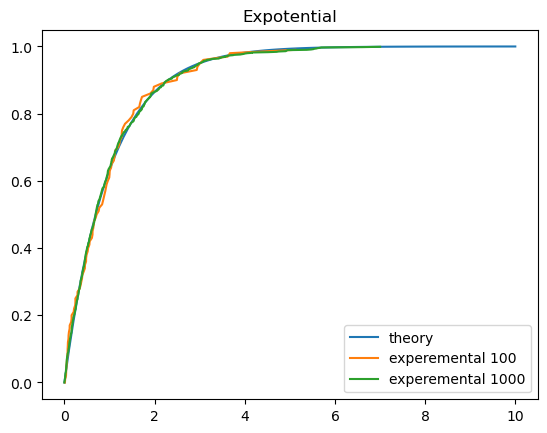

In [466]:
plt.figure(dpi=100)
plt.title('Experemental')
plt.plot(theory_exp_x, theory_exp_y, label='theory')
plt.plot(exp_100_copy, exp_100_copy_y, label='experemental 100')
plt.plot(exp_1000_copy, exp_1000_copy_y, label='experemental 1000')
plt.legend()
plt.show()

<h3> Задание 1.5 </h3>
Построили плотность распределения случайной величины на основе
выборки (на одном графике показали плотности распределения,
полученные из выборок разного размера и теоретическую).

In [467]:
def exp_S(l, x):
    return l*np.exp(-l*x)

In [468]:
theory_exp_S_x = np.linspace(0,10,100)
theory_exp_S_y = exp_S(1, theory_exp_S_x)


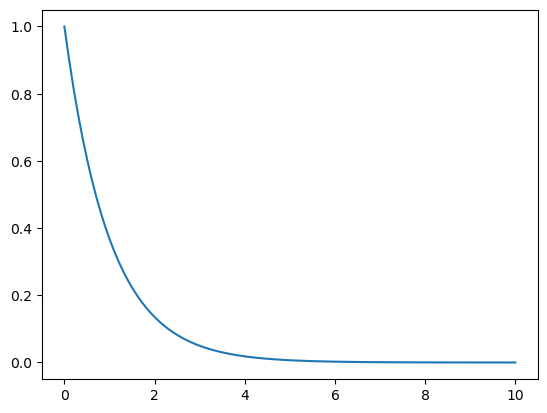

In [469]:
plt.plot(theory_exp_S_x, theory_exp_S_y)

In [470]:
def norm_p(x, m, s):
     return 1/(s*np.sqrt(2*np.pi))*np.exp(-0.5*((x-m)/s)**2)

In [471]:
theory_norm_S_x = np.linspace(-3, 3, 100)
theory_norm_S_y = norm_p(theory_norm_S_x, 0, 1)

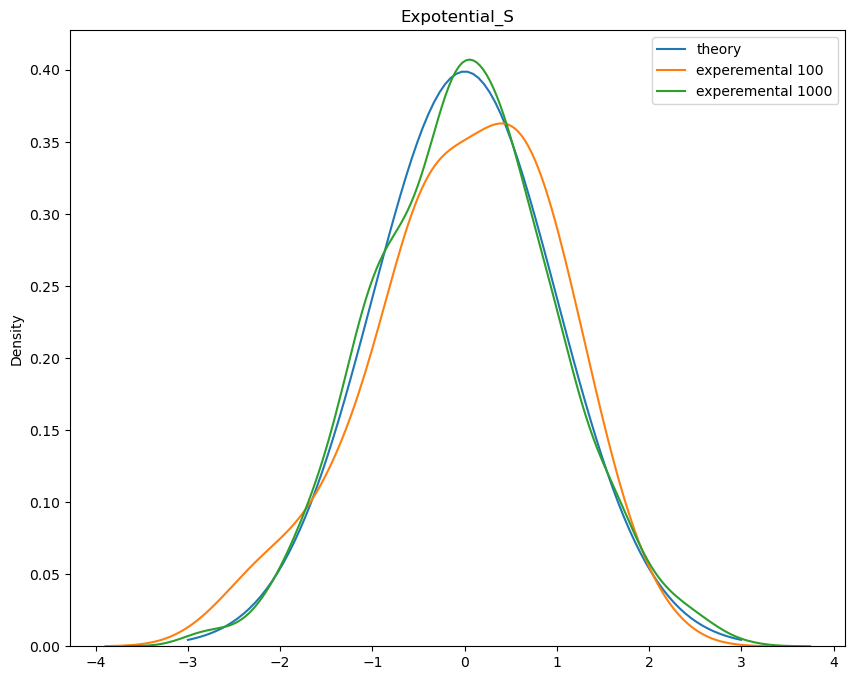

In [472]:
plt.figure(figsize=(10,8))

plt.title('Experemental_S')
plt.plot(theory_norm_S_x, theory_norm_S_y, label="theory")
sns.kdeplot(norm_100, label="experemental 100")
sns.kdeplot(norm_1000, label="experemental 1000")
plt.legend()

Из полученных графиков делаем вывод, что точность апроксимации увеличивается с ростом количества эксперементов.

<h3> Задание 2 </h3>
Сгенерировали три выборки размера 100, 1000 и 10000 для случайных
расстояний между двумя точками, равномерно распределенные в
прямоугольнике со сторонами 10 и 30. Получили среднее значение
расстояния между точками, построили функцию распределения
вероятностей и плотности вероятностей случайных расстояний. Показали
разницу между соответствующими функциями на одном графике

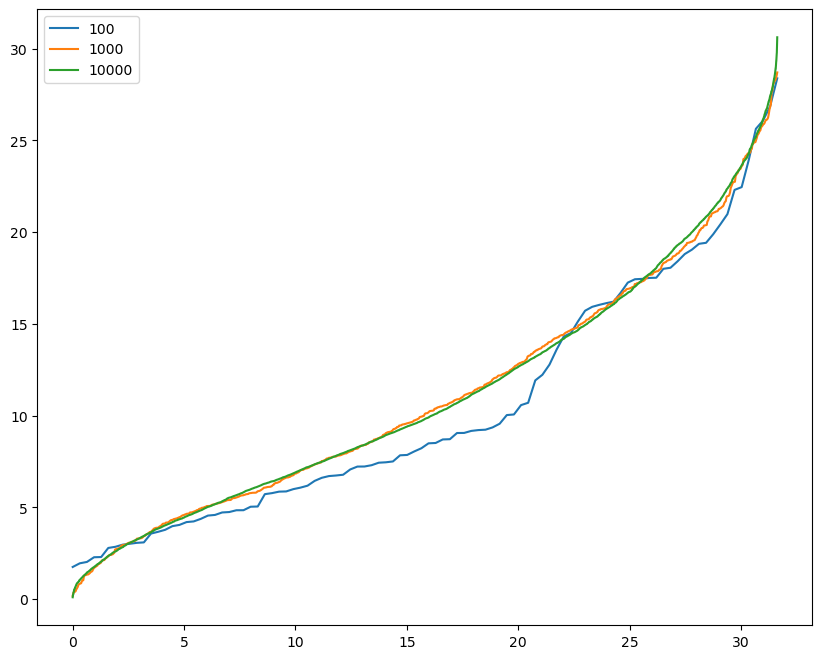

In [473]:
a = 10
b = 30 
def dist(x1,y1,x2,y2):
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)
def create_d(length):
    D = []
    for i in range(length):
        x1,x2 = np.random.uniform(0,a),np.random.uniform(0,a)
        y1,y2 = np.random.uniform(0,b),np.random.uniform(0,b)
        D.append(dist(x1,y1,x2,y2))
    D.sort()
    return D
l100 = create_d(100)
l1000 = create_d(1000)
l10000 = create_d(10000)
x100 = np.linspace(0, np.sqrt(a*a + b*b), 100)
x1000 = np.linspace(0, np.sqrt(a*a + b*b), 1000)
x10000 = np.linspace(0, np.sqrt(a*a + b*b), 10000)
plt.figure(figsize=(10,8))

plt.plot(x100, l100, label="100")
plt.plot(x1000, l1000, label="1000")
plt.plot(x10000, l10000, label="10000")
plt.legend()

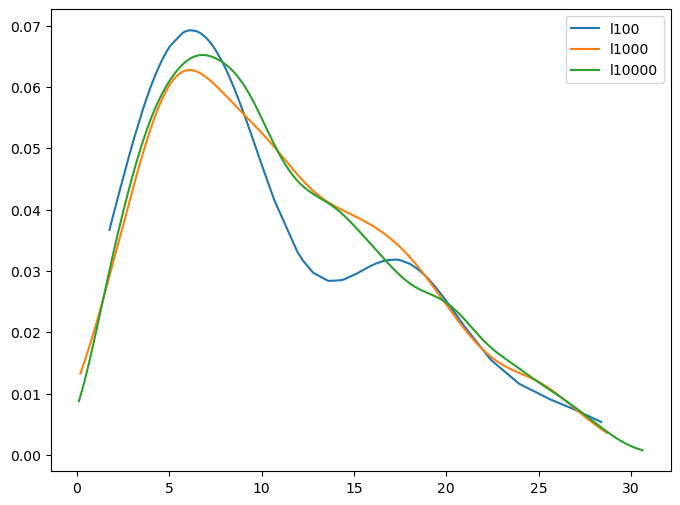

In [474]:
kde_dist_1_y = gaussian_kde(l100).evaluate(l100)
kde_dist_2_y = gaussian_kde(l1000).evaluate(l1000)
kde_dist_3_y = gaussian_kde(l10000).evaluate(l10000)
plt.figure(figsize=(8,6))

plt.plot(l100, kde_dist_1_y, label="l100")
plt.plot(l1000, kde_dist_2_y, label="l1000")
plt.plot(l10000, kde_dist_3_y, label="l10000")

plt.legend()

In [ ]:
<h3> Вывод </h3>
В ходе выполнения лабораторной работы были исследованы етоды оценки статических характеристик, связанных с
распределением пользователей на плоскости.
